In [1]:
from typing_extensions import TypedDict

In [2]:
class OverallState(TypedDict):
    subjects: list[str]
    results: list[str]

In [3]:
class WorkerState(TypedDict):
    subject: list[str]

In [4]:
def worker(state: WorkerState):
    print(f"working on {state['subject']}")
    return [f"results for {state['subject']}"]

In [5]:
from langgraph.types import Send

c:\Users\jehoo\AppData\Local\anaconda3\envs\all_env\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [6]:
def orchestrator(state: OverallState):
    return [
        Send("worker", {"subject": subject}) 
        for subject in state['subjects']
        ]

In [7]:
from langgraph.graph import START, END, StateGraph

In [10]:
builder = StateGraph(OverallState)

builder.add_node("worker", worker)

builder.add_conditional_edges(
    START,
    orchestrator
)

builder.add_edge("worker", END)

graph = builder.compile()

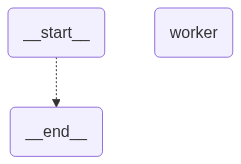

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))